## PART A

### Medical Domain

In [409]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

### 1. Data Understanding

**A. Read all the 3 CSV files as DataFrame and store them into 3 separate variables.**


In [410]:
normal=pd.read_csv("Normal.csv")
h=pd.read_csv("Type_H.csv")
s=pd.read_csv("Type_S.csv")

**B. Print Shape and columns of all the 3 DataFrames.**

In [411]:
print("Shape of Dataframe Normal is ",normal.shape)
print("Shape of Dataframe Type H is ",h.shape)
print("Shape of Dataframe Type S is ",s.shape)

Shape of Dataframe Normal is  (100, 7)
Shape of Dataframe Type H is  (60, 7)
Shape of Dataframe Type S is  (150, 7)


In [412]:
print("Columns in Dataframe Normal are ",normal.columns)
print("Columns in Dataframe Type H are ",h.columns)
print("Columns in Dataframe Type S are ",s.columns)

Columns in Dataframe Normal are  Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')
Columns in Dataframe Type H are  Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')
Columns in Dataframe Type S are  Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')


In [413]:
normal.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,Normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,Normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,Normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,Normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,Normal


In [414]:
normal["Class"].unique()

array(['Normal', 'Nrmal'], dtype=object)

In [415]:
h.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Type_H
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Type_H
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Type_H
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Type_H
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Type_H


In [416]:
s.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,74.377678,32.053104,78.772013,42.324573,143.560690,56.125906,Type_S
1,89.680567,32.704435,83.130732,56.976132,129.955476,92.027277,Type_S
2,44.529051,9.433234,52.000000,35.095817,134.711772,29.106575,Type_S
3,77.690577,21.380645,64.429442,56.309932,114.818751,26.931841,Type_S
4,76.147212,21.936186,82.961502,54.211027,123.932010,10.431972,Type_S


In [417]:
h["Class"].unique()

array(['Type_H', 'type_h'], dtype=object)

In [418]:
s["Class"].unique()

array(['Type_S', 'tp_s'], dtype=object)

**C. Compare Column names of all the 3 DataFrames and clearly write observations.**

- All the 3 Dataframes have the same column names.
- The dataframes are categorised based on the value in the column "Class". 
- Each row in the dataframes represents a patient and each column corresponds to the biometrics of that patient
- Based on the biometrics, a patient is categorised as either Normal, Type S or Type H.

**D. Print DataTypes of all the 3 DataFrames.**

In [419]:
normal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_incidence  100 non-null    float64
 1   P_tilt       100 non-null    float64
 2   L_angle      100 non-null    float64
 3   S_slope      100 non-null    float64
 4   P_radius     100 non-null    float64
 5   S_Degree     100 non-null    float64
 6   Class        100 non-null    object 
dtypes: float64(6), object(1)
memory usage: 5.6+ KB


In [420]:
h.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_incidence  60 non-null     float64
 1   P_tilt       60 non-null     float64
 2   L_angle      60 non-null     float64
 3   S_slope      60 non-null     float64
 4   P_radius     60 non-null     float64
 5   S_Degree     60 non-null     float64
 6   Class        60 non-null     object 
dtypes: float64(6), object(1)
memory usage: 3.4+ KB


In [421]:
s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_incidence  150 non-null    float64
 1   P_tilt       150 non-null    float64
 2   L_angle      150 non-null    float64
 3   S_slope      150 non-null    float64
 4   P_radius     150 non-null    float64
 5   S_Degree     150 non-null    float64
 6   Class        150 non-null    object 
dtypes: float64(6), object(1)
memory usage: 8.3+ KB


**E. Observe and share variation in ‘Class’ feature of all the 3 DaraFrames.**

In [422]:
normal["Class"].value_counts()

Normal    73
Nrmal     27
Name: Class, dtype: int64

In [423]:
h["Class"].value_counts()

Type_H    37
type_h    23
Name: Class, dtype: int64

In [424]:
s["Class"].value_counts()

Type_S    133
tp_s       17
Name: Class, dtype: int64

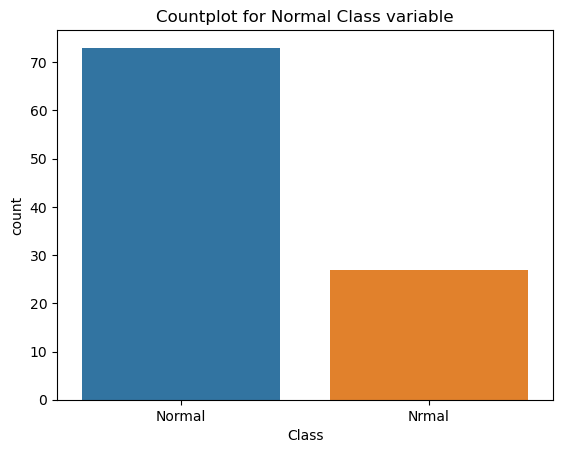

In [425]:
sns.countplot(normal,x="Class")
plt.title("Countplot for Normal Class variable")
plt.show();

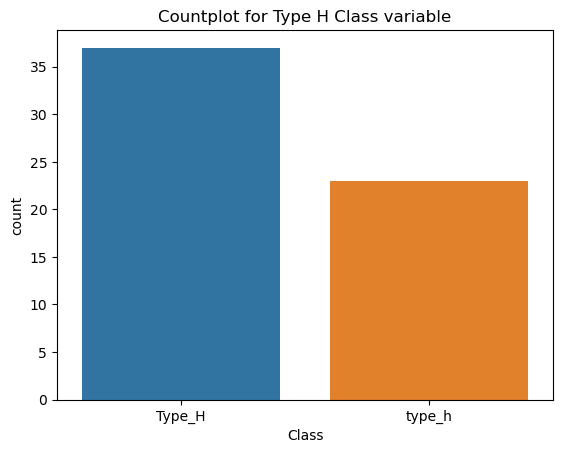

In [426]:
sns.countplot(h,x="Class")
plt.title("Countplot for Type H Class variable")
plt.show();

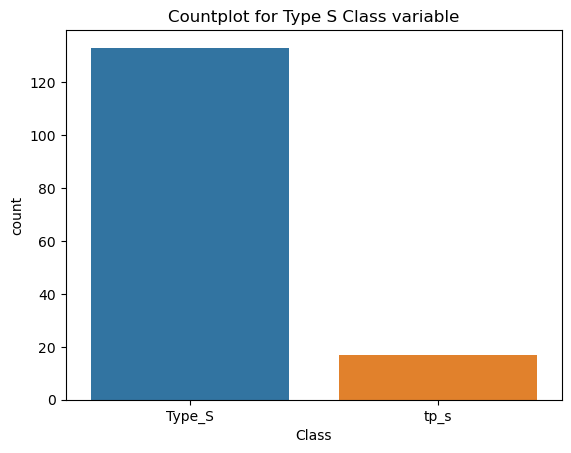

In [427]:
sns.countplot(s,x="Class")
plt.title("Countplot for Type S Class variable")
plt.show();

Observations in the Class feature of the dataframes:
- Datapoints in the normal class corresponds to the biometrics of patients that are "Normal"
- Similarly the datapoints in Type H and Type S corresponds to the biometrics of patients that are Type H and Type S respectively.
- Normal class has 100 datapoints, Type H has 60 datapoints and Type S has 150 datapoints
- Datatype for the 3 classes is int but they can be converted to Objects or category after sanity check of the values in the dataframe

### 2. Data Preparation and Exploration

**A. Unify all the variations in ‘Class’ feature for all the 3 DataFrames.**

- In the Normal dataframe, there are 2 unique values and those are Normal and Nrmal.
- 73 values are correctly defined as Normal, while 27 has the value Normal written as Nrmal.
- In the Type H dataframe, there are 2 unique values and those are Type_H and type_h.
- 37 values are correctly defined as Type_H, while 23 has the value Type_H written as type_h.
- We can change the 23 values from type_h tp Type_H
- In the Type S dataframe, there are 2 unique values and those are Type_S and tp_s.
- 133 values are correctly defined as Type_S, while 17 has the value Type_S written as tp_s.
- We can change the 17 values from tp_s tp Type_S

In [428]:
normal["Class"]=normal["Class"].replace("Nrmal","Normal")

In [429]:
h["Class"]=h["Class"].replace("type_h","Type_H")

In [430]:
s["Class"]=s["Class"].replace("tp_s","Type_S")

In [431]:
normal["Class"].unique()

array(['Normal'], dtype=object)

In [432]:
h["Class"].unique()

array(['Type_H'], dtype=object)

In [433]:
s["Class"].unique()

array(['Type_S'], dtype=object)

**B. Combine all the 3 DataFrames to form a single DataFrame.**

In [434]:
details=pd.concat([normal,h,s],axis=0)

In [435]:
details.shape

(310, 7)

**C. Print 5 random samples of this DataFrame**

In [436]:
details.sample(5)

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
6,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Type_H
74,59.167612,14.562749,43.199158,44.604863,121.035642,2.830504,Normal
28,56.605771,16.800200,42.000000,39.805571,127.294522,24.018575,Type_S
97,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,Normal
138,74.854480,13.909084,62.693259,60.945396,115.208701,33.172255,Type_S


**D. Print Feature-wise percentage of Null values.**

In [437]:
details.columns

Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')

In [438]:
details["P_incidence"].isnull().value_counts(normalize=True)

False    1.0
Name: P_incidence, dtype: float64

In [439]:
details["P_tilt"].isnull().value_counts(normalize=True)

False    1.0
Name: P_tilt, dtype: float64

In [440]:
details["L_angle"].isnull().value_counts(normalize=True)

False    1.0
Name: L_angle, dtype: float64

In [441]:
details["S_slope"].isnull().value_counts(normalize=True)

False    1.0
Name: S_slope, dtype: float64

In [442]:
details["P_radius"].isnull().value_counts(normalize=True)

False    1.0
Name: P_radius, dtype: float64

In [443]:
details["S_Degree"].isnull().value_counts(normalize=True)

False    1.0
Name: S_Degree, dtype: float64

In [444]:
details["Class"].isnull().value_counts(normalize=True)

False    1.0
Name: Class, dtype: float64

There are no null values in any of the 7 features in the dataframe details (formed by combining the 3 dataframes, Normal, Type H and Type S)

In [445]:
print("The Feature wise % of null values for each of the feature in the details dataframe is 0%")

The Feature wise % of null values for each of the feature in the details dataframe is 0%


**E. Check 5-point summary of the new DataFrame.**

The 5-point summary of any dataframe are the minimum value, maximum value, 25th percentile, median, 75th percentile. we can also get the standard deviation and mean of each of the attributes in the dataframe.

In [446]:
details.describe().T

,count,mean,std,min,25%,50%,75%,max
P_incidence,310.0,60.496653,17.236520,26.147921,46.430294,58.691038,72.877696,129.834041
P_tilt,310.0,17.542822,10.008330,-6.554948,10.667069,16.357689,22.120395,49.431864
L_angle,310.0,51.930930,18.554064,14.000000,37.000000,49.562398,63.000000,125.742385
S_slope,310.0,42.953831,13.423102,13.366931,33.347122,42.404912,52.695888,121.429566
P_radius,310.0,117.920655,13.317377,70.082575,110.709196,118.268178,125.467674,163.071041
S_Degree,310.0,26.296694,37.559027,-11.058179,1.603727,11.767934,41.287352,418.543082


Observations on the 5 points summary:
- S_Degree is likely to have outliers since there is a huge difference from the 75th percentile to the max value.
- Similarly P_incidence, L_angle and S_slope
- S_Degree has a mean of 26.29 whereas the maximum value is 419
- Mean and the 50th Percentile(median) is almost the same for the below features
     - P_incidence
     - P_tilt
     - L_angle
     - S_slope
     - P_radius

### 3. Data Analysis

**A. Visualize a heatmap to understand correlation between all features**

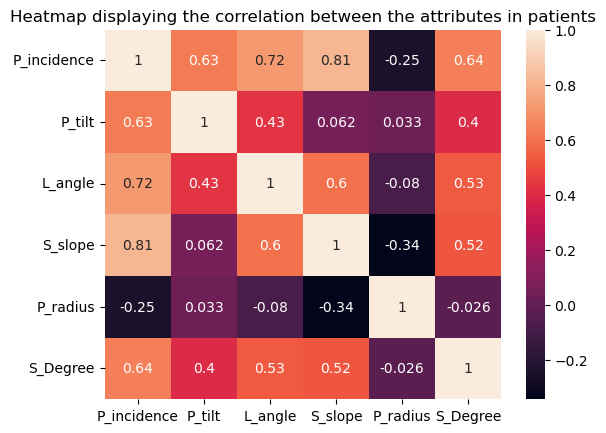

In [447]:
sns.heatmap(details.drop("Class",axis=1).corr(),annot=True)
plt.title("Heatmap displaying the correlation between the attributes in patients")
plt.show();

**B. Share insights on correlation. <br />
&nbsp; &nbsp; A. Features having stronger correlation with correlation value.<br />
&nbsp;  &nbsp; B. Features having weaker correlation with correlation value.**

- Highest correlation is a positive correlation between S_slope and P_incidence with a value of 0.81
- Weakest correlation is between S_degree and P_radius with a value of 0.026
- Some features have almost the same correlation to another feature
  - L_angle and S_slope has almost the same correlation with S_Degree (0.53 and 0.52 respectively)
  - P_tilt and S_Degree has almost the same correlation with P_incidence (0.63 and 0.64 respectively)
  - L_angle and S_Degree has almost the same correlation with P_tilt (0.43 and 0.4 respectively)
- P_radius has almost no correlation with any of the other features

**C. Visualize a pairplot with 3 classes distinguished by colors and share insights.**

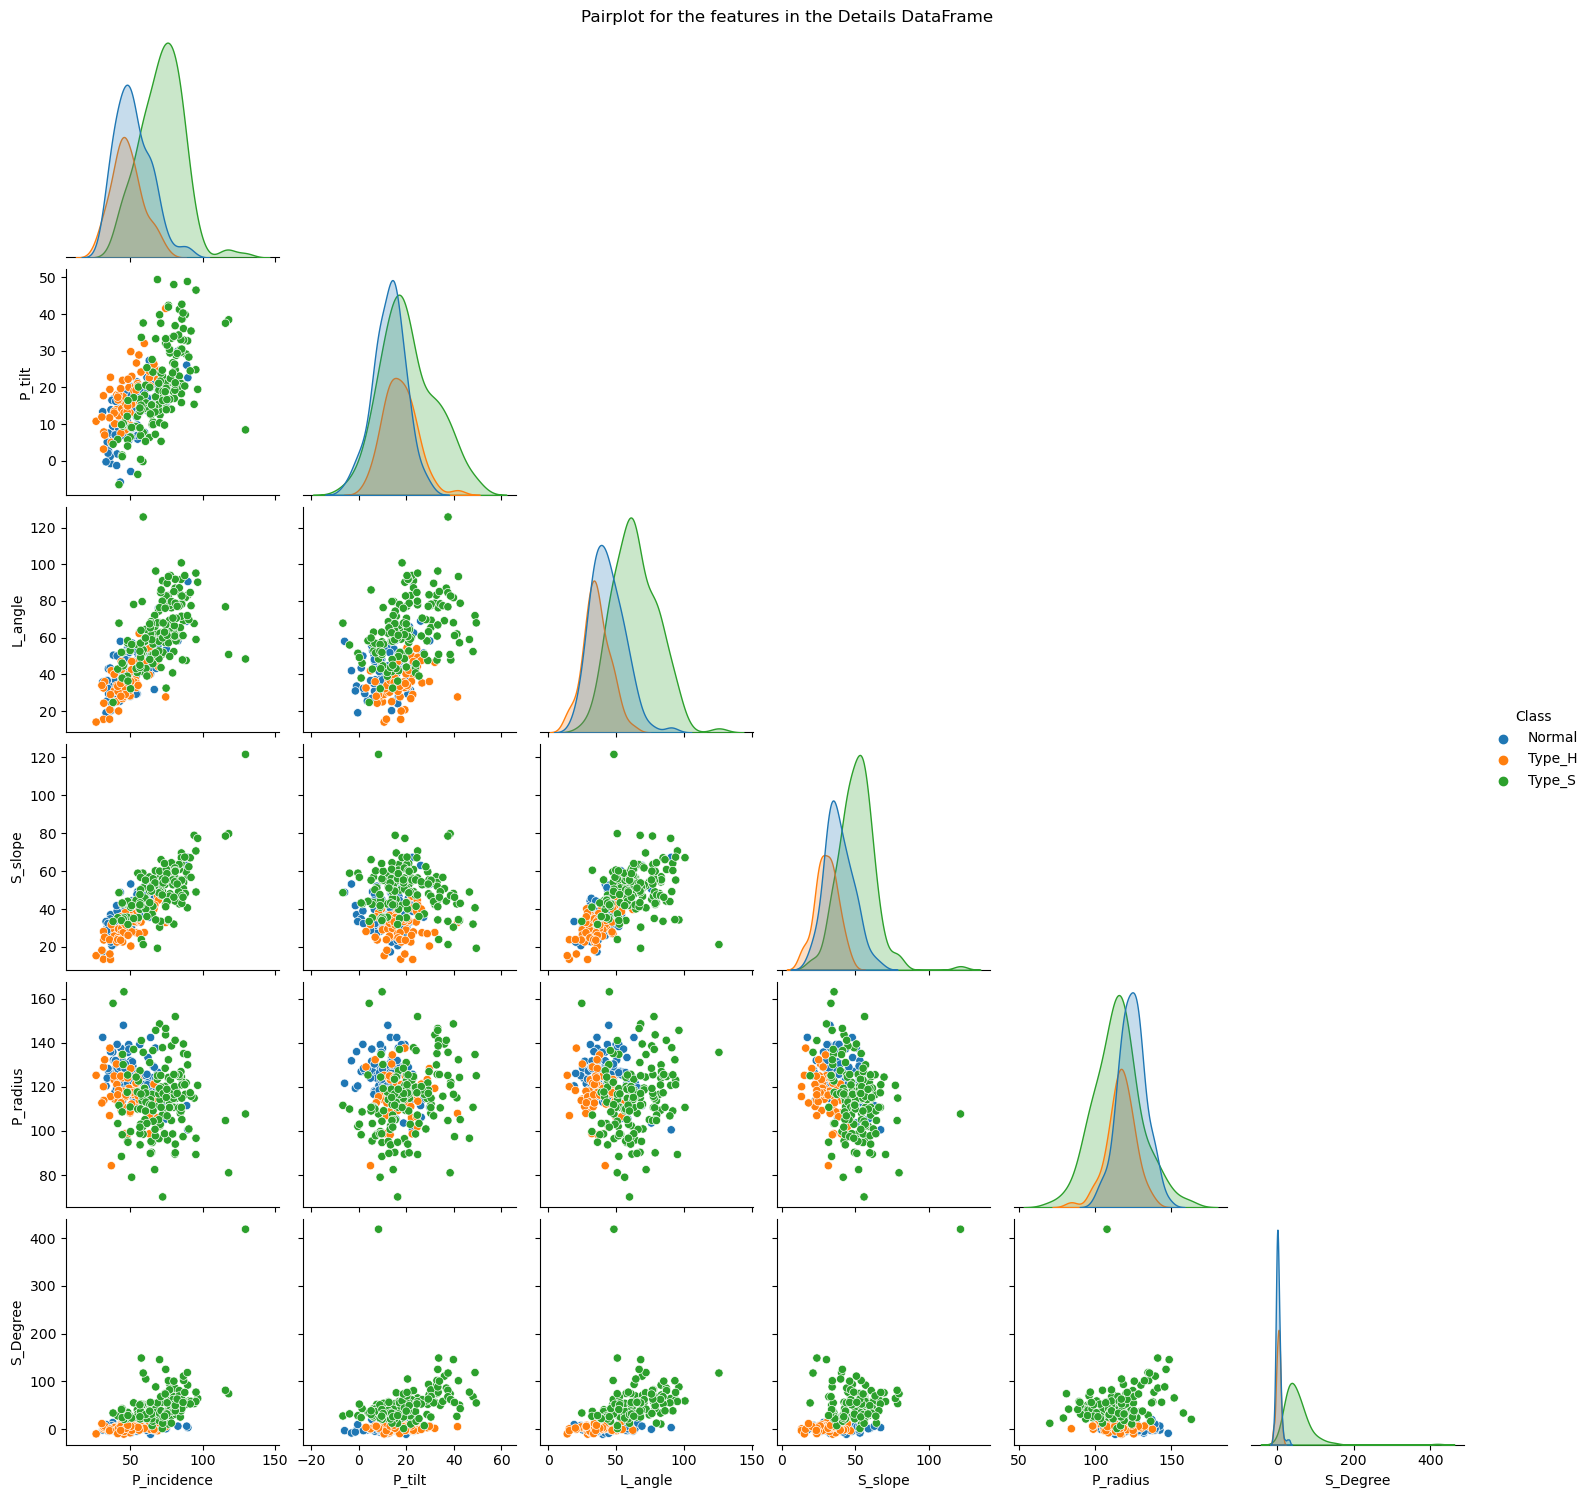

In [448]:
g = sns.pairplot(details,hue="Class",corner=True)
g.fig.suptitle("Pairplot for the features in the Details DataFrame", y=1)
plt.show();

- S-Degree tends to have almost no correlation P_radius
- Value of S_degree is usually low for class H-type and class Normal
- scatter plot for P-radius does not show any pattern which clearly shows that there is no correlation between P_radius and the other attributes in the dataframe.
- S_slope has a strong positive correlation between P_incidence and L_angle
- scatter plot for S_slope and P_tile does not display any pattern so we can infer that they do not have a correlation 
- S_Slope tends to have low values for classes Type H and Normal
- L_angle has a strong correlation with P_incidence and a noticeable positive correlation with p_tilt
- P_tile has a strong correlation with P_incidence
- Most of the Type H features tend to have low values except for P_radius and P_tilt
- Features with the highest values is mostly with the class Type S

**D. Visualize a jointplot for ‘P_incidence’ and ‘S_slope’ and share insights.**

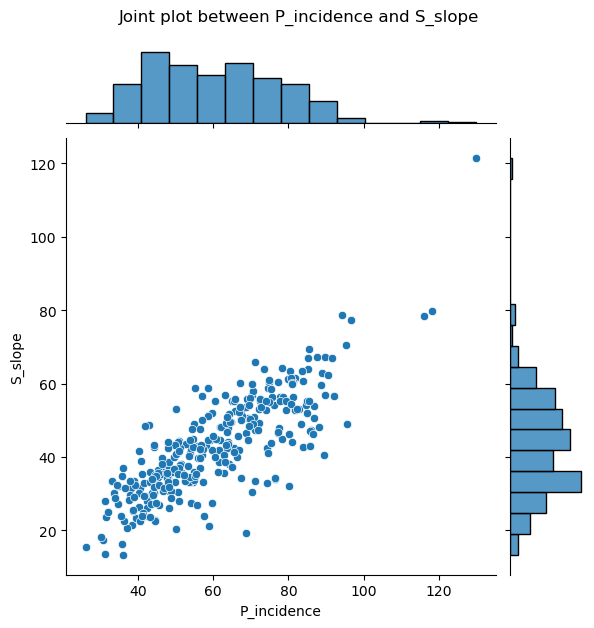

In [449]:
p = sns.jointplot(details,x="P_incidence",y="S_slope")
p.fig.suptitle("Joint plot between P_incidence and S_slope",y=1.04);

- P_incidence and S_slope has a positive correlation.
- S_slope has values ranging from 10 to 120
- P_incidence has values ranging from 5 to 130
- S_slope has most of the values in the range of 35 and 38
- P_incidence has most of the values in the range 41 and 44
- plot for S_slope and P_incidence are right skewed

**E. Visualize a boxplot to check distribution of the features and share insights.**

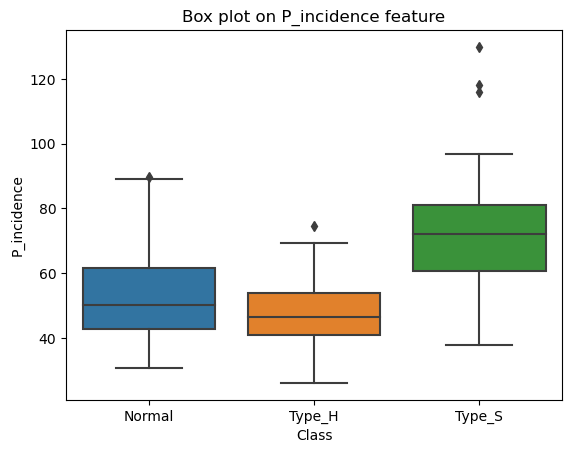

In [450]:
sns.boxplot(details,y="P_incidence", x="Class")
plt.title("Box plot on P_incidence feature")
plt.show();

Inferences on the Box plot for P_incidence feature
 - Type S tends to have higher P_incidence values when compared to Normal and Type H
 - Normal and Type H class have values clustered around almost the same median.
 - Normal Class has a slightly right skewed data
 - Type S has a slightly left skewed data.
 - Type H does not have any skewness.
 - There are more outliers in Type S class when compared to Type H and Normal class

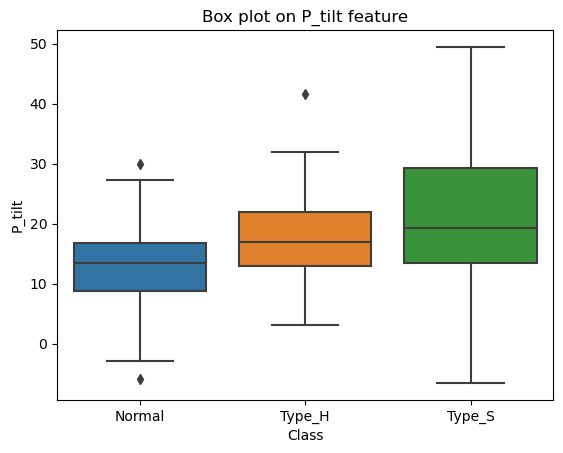

In [451]:
sns.boxplot(details,y="P_tilt", x="Class")
plt.title("Box plot on P_tilt feature")
plt.show();

Inferences on the Box plot for P_tilt feature
 - The Type S has widely spread out data points
 - The lowest and the highest value for P_tilt is that for Type S
 - The P_Tilt values are clustered around almost the same value for Type S and Type H class
 - Normal Class has outliers on both sides
 - Type S does not have any outliers

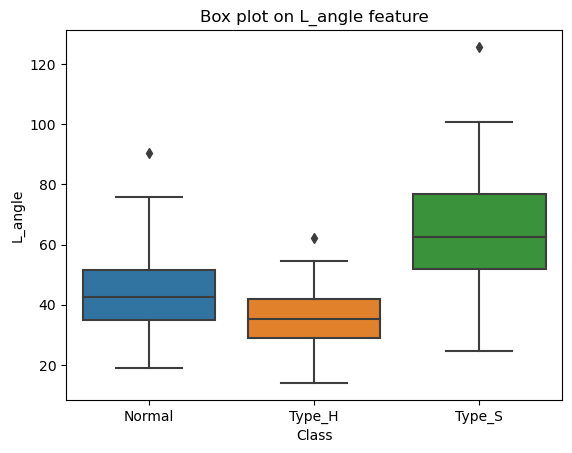

In [452]:
sns.boxplot(details,y="L_angle", x="Class")
plt.title("Box plot on L_angle feature")
plt.show();

Inferences on the Box plot for L_angle feature
 - Type S tends to have higher values for L-angle when compared to Normal and Type H
 - Outliers are present for all the 3 types of classes but not many.
 - Type H has the least value for L_angle and Type S has the highest value for L_angle

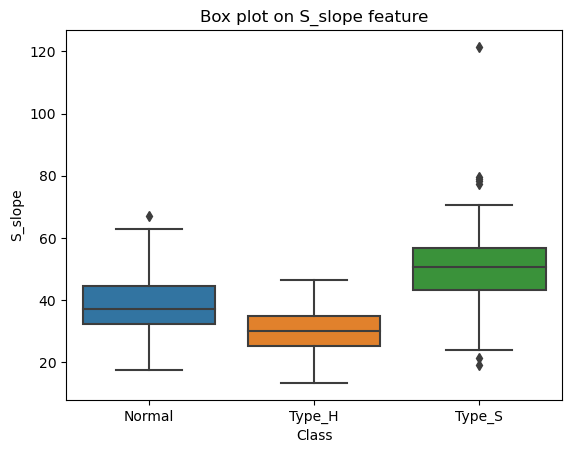

In [453]:
sns.boxplot(details,y="S_slope", x="Class")
plt.title("Box plot on S_slope feature")
plt.show();

Inferences on the Box plot for S_slope feature
- Type S has many outliers when compared to Normal class while Type H has no outliers
- Type S class has the the highest value for S_slope while the least value is almost same for Type H and Normal class

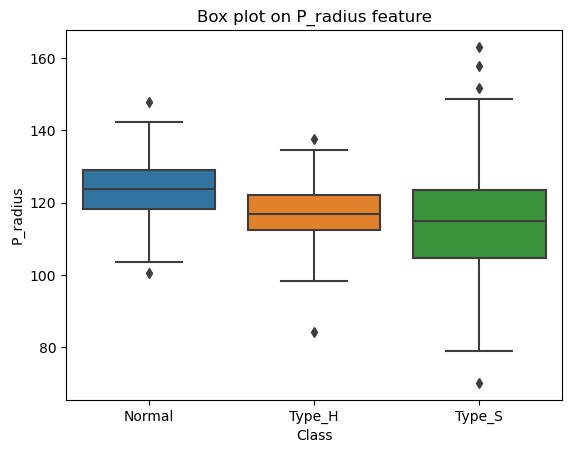

In [454]:
sns.boxplot(details,y="P_radius", x="Class")
plt.title("Box plot on P_radius feature")
plt.show();

Inferences on the Box plot for P_radius feature
 - Ourliers are present for all the 3 classes with Tupe S having the maximum number of outliers
 - The range of values for Type S is more when compared to that for Normal and Type H
 

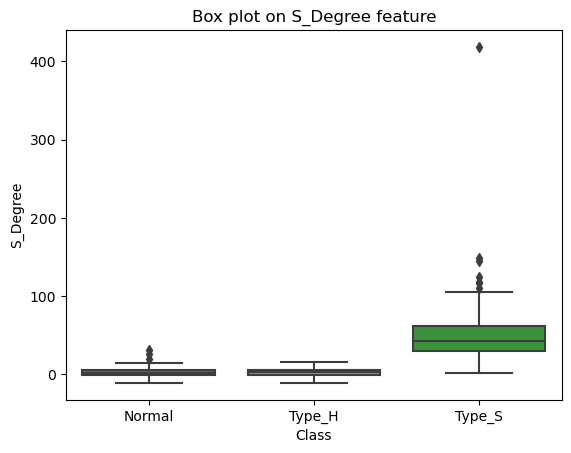

In [455]:
sns.boxplot(details,y="S_Degree", x="Class")
plt.title("Box plot on S_Degree feature")
plt.show();

Inferences on the Box plot for S_Degree feature
 - The range of values is very less for Normal and Type H
 - Type S has a wide range of values when compared to the other 2 classes
 - Normal and Type H has almost the same values while there are outliers in Normal and no outliers for Type H
 - Outliers are present in Type S calss

### 4. Model Building

**A. Split data into X and Y.**

In [456]:
details.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 310 entries, 0 to 149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   P_incidence  310 non-null    float64
 1   P_tilt       310 non-null    float64
 2   L_angle      310 non-null    float64
 3   S_slope      310 non-null    float64
 4   P_radius     310 non-null    float64
 5   S_Degree     310 non-null    float64
 6   Class        310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 19.4+ KB


In [457]:
#Encoding the target variable
Lab_enc=LabelEncoder()
details["Class"]=Lab_enc.fit_transform(details["Class"])
details["Class"].value_counts()

2    150
0    100
1     60
Name: Class, dtype: int64

Labels correponding to the encoded values are

- Normal=0
- Type H=1
- Type S=2

In [464]:
#Converting the class back to categorical
details["Class"]=details["Class"].astype("category")

In [465]:
X=details.drop("Class", axis=1)
y=details["Class"]

In [466]:
X

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910
...,...,...,...,...,...,...
145,80.111572,33.942432,85.101608,46.169139,125.593624,100.292107
146,95.480229,46.550053,59.000000,48.930176,96.683903,77.283072
147,74.094731,18.823727,76.032156,55.271004,128.405731,73.388216
148,87.679087,20.365613,93.822416,67.313473,120.944829,76.730629


In [467]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Class, Length: 310, dtype: category
Categories (3, int64): [0, 1, 2]

In [468]:
#When using KNN classifier it is very important that the training and testing data should be scaled.
#Hence scaling the data using Zscore
Xscaled=X.apply(zscore)

**B. Split data into train and test with 80:20 proportion**

In [469]:
# Split X and y into training and test set in 80:20 ratio

X_train, X_test, y_train, y_test = train_test_split(Xscaled, y, test_size=0.20, random_state=1)

**C. Train a Supervised Learning Classification base model using KNN classifier.**

In [470]:
#Base Model
NNH = KNeighborsClassifier()

In [471]:
NNH.fit(X_train, y_train)

KNeighborsClassifier()

In [472]:
predicted_labels = NNH.predict(X_test)
predicted_labels

array([2, 2, 0, 0, 0, 1, 2, 1, 1, 2, 1, 2, 0, 1, 2, 1, 2, 2, 2, 0, 2, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 2, 1, 1, 2, 2, 0, 2,
       1, 1, 2, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 0, 0, 2], dtype=int64)

**D. Print all the possible performance metrics for both train and test data.**

In [473]:
NNH.score(X_train, y_train)

0.8467741935483871

In [474]:
NNH.score(X_test, y_test)

0.7258064516129032

Accuracy of the training data is 0.85 while the same for testing data is 0.73. <br>
This is because of overfitting

In [477]:
print("Confusion Matrix")
cm=metrics.confusion_matrix(y_test, predicted_labels, labels=[0, 1,2])

df_cm = pd.DataFrame(cm, index = [i for i in ["Normal","Type_H","Type_S"]],
                  columns = [i for i in ["Predict Normal","Predict H","Predict S"]])
df_cm

Confusion Matrix


,Predict Normal,Predict H,Predict S
Normal,12,2,4
Type_H,4,7,0
Type_S,5,2,26


Confusion matrix represented pictorially


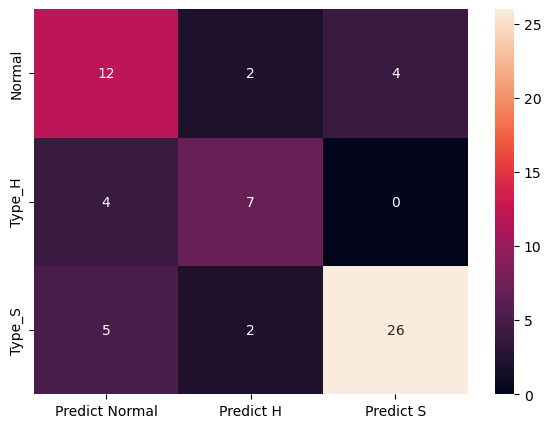

In [478]:
print("Confusion matrix represented pictorially")
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)
plt.show();

In [480]:
print("Classification Report")
print(metrics.classification_report(y_test, predicted_labels, labels=[0, 1,2]))

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.67      0.62        18
           1       0.64      0.64      0.64        11
           2       0.87      0.79      0.83        33

    accuracy                           0.73        62
   macro avg       0.69      0.70      0.69        62
weighted avg       0.74      0.73      0.73        62



Out of all the predicted normal class, 57% of time the predictions were correct<br>
Out of all the predicted Type S class, 87% od times the predictions were correct<br>
64% of times, Type H class predictions were correct<br>

67% of the actual Normal was identified correctly<br>
79% of the actual Type S was identified correctly<br>
64% of the actual Type H was identified correctly<br>

Precision and Recall balance is maximum for Type S class <br>
Normal and Type H has almost the same precision and Recall balance.

### 5. Performance Improvement

**A. Experiment with various parameters to improve performance of the base model.**

For a KNN Classifier let us examine the parameters that are passed. 
 - n_neighbors - number of nearest neighbour
 - weights - uniform or distance - uniform weights. All points in each neighborhood are weighted equally. weight points by the    inverse of their distance. 
 - algorithm - ball_tree’ will use BallTree ,‘kd_tree’ will use KDTree, ‘brute’ will use a brute-force search.
 - Leaf size passed to BallTree or KDTree. 
 - Power parameter for the Minkowski metric. When p = 1, manhattan_distance and euclidean_distance for p = 2. 
 
Let us use grid search technique in finding out the best parameters for the KNN algorithm

In [481]:
#pip uninstall scikit-learn

In [236]:
#pip install scikit-learn==1.2.2

In [237]:
n_neighbors = list(range(3,20))
#weights = ["uniform", "distance"]
#algorithm = ["ball_tree", "kd_tree", "brute"]
leaf_size = list(range(1,20))
p=[1,2]
#Convert to dictionary
#hyperparameters = dict(n_neighbors=n_neighbors,weights=weights,algorithm=algorithm,leaf_size=leaf_size, p=p)
hyperparameters = dict(n_neighbors=n_neighbors,leaf_size=leaf_size, p=p)
#Create new KNN object
NNH2 = KNeighborsClassifier()
#Use GridSearch
clf = GridSearchCV(NNH2, hyperparameters, cv=10)
#Fit the model
best_model = clf.fit(X_train, y_train)
#Print The value of best Hyperparameters
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])
#print('Best weights:', best_model.best_estimator_.get_params()['weights'])
#print('Best algorithm:', best_model.best_estimator_.get_params()['algorithm'])
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])

Best n_neighbors: 7
Best leaf_size: 1
Best p: 2


In [238]:
n_neighbors = list(range(3,20))
weights = ["uniform", "distance"]
algorithm = ["ball_tree", "kd_tree", "brute"]
leaf_size = list(range(1,20))
p=[1,2]
#Convert to dictionary
hyperparameters = dict(n_neighbors=n_neighbors,weights=weights,algorithm=algorithm,leaf_size=leaf_size, p=p)
#hyperparameters = dict(n_neighbors=n_neighbors,leaf_size=leaf_size, p=p)
#Create new KNN object
NNH2 = KNeighborsClassifier()
#Use GridSearch
clf = GridSearchCV(NNH2, hyperparameters, cv=10)
#Fit the model
best_model = clf.fit(X_train, y_train)
print("The value of best Hyperparameters")
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])
print('Best weights:', best_model.best_estimator_.get_params()['weights'])
print('Best algorithm:', best_model.best_estimator_.get_params()['algorithm'])
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])

The value of best Hyperparameters
Best n_neighbors: 14
Best weights: distance
Best algorithm: ball_tree
Best leaf_size: 1
Best p: 1


Creating the model using the tuned parameters

In [482]:
#Model 1
NNH3 = KNeighborsClassifier(n_neighbors= 14 , leaf_size=1, weights = 'distance',algorithm="ball_tree",p=1 )
NNH3.fit(X_train, y_train)


print("Score on Training Data: ",NNH3.score(X_train, y_train))
print("Score on Testing Data: ",NNH3.score(X_test, y_test))

predicted_labels3 = NNH3.predict(X_test)

print("Classification Report for SVM Model")
print("__"*30)
print(metrics.classification_report(y_test,predicted_labels3,labels=[0, 1,2]))

Score on Training Data:  1.0
Score on Testing Data:  0.7419354838709677
Classification Report for SVM Model
____________________________________________________________
              precision    recall  f1-score   support

           0       0.60      0.67      0.63        18
           1       0.67      0.73      0.70        11
           2       0.87      0.79      0.83        33

    accuracy                           0.74        62
   macro avg       0.71      0.73      0.72        62
weighted avg       0.75      0.74      0.75        62



In [484]:
#Model 2
NNH4_1 = KNeighborsClassifier(n_neighbors= 7 , leaf_size=1,p=2 )
NNH4_1.fit(X_train, y_train)

print("Score on Training Data: ",NNH4_1.score(X_train, y_train))
print("Score on Testing Data: ",NNH4_1.score(X_test, y_test))

predicted_labels4_1 = NNH4_1.predict(X_test)

print("Classification Report")
print(metrics.classification_report(y_test, predicted_labels4_1, labels=[0, 1,2]))

Score on Training Data:  0.8346774193548387
Score on Testing Data:  0.7580645161290323
Classification Report
              precision    recall  f1-score   support

           0       0.60      0.67      0.63        18
           1       0.75      0.82      0.78        11
           2       0.87      0.79      0.83        33

    accuracy                           0.76        62
   macro avg       0.74      0.76      0.75        62
weighted avg       0.77      0.76      0.76        62



**B. Clearly showcase improvement in performance achieved.** <br>

**For Example:**
- **A. Accuracy: +15% improvement**
- **B. Precision: +10% improvement**

Base model: all parameters set to default value <br>
Model 1: Tuning parameters(n_neighbours, leaf_size, weights, algorithm, p)<br>
Model 2: Tuning parameters(n_neighbours , leaf_size ,p)<br>

 - Base model has an accuracy of 73%
 - Precision for the "Normal" class is only 57 % for base model
 - Accuracy in training data is 100% for Model 1 while the same for testing data is only 74%  and hence the model is overfitting the training data


- When comparing Models 1 and 2 
    - Scores for Normal and Type S are identical for Model 1 and Model 2
    - There is significant improvement in the scores for the Type H in Model 2 when compared to Model 1
 Hence we can conclude that Model 2 is a better choice <br>
 
 Performance improvements in Model 2 when comparing with Base model
  - Scores for Normal class
     - Precision: +3% improvement
     - F1-score: +1% improvement
  - Scores for Type H class
     - Precision: +11% improvement
     - Recall: +18% improvement
     - F1-score: +14% improvement
   - Accuracy: +3% improvement
   
   
There is evident improvement in the scores for the Model 2 wrt to the base model.
Hence we can conclude that Model 2 is a better model.

Let us now validate if the k value that has been considered is the best

In [485]:
test_score =[]
train_score =[]
for k in range(1,30):
    NNH2 = KNeighborsClassifier(n_neighbors = k,leaf_size=1,p=1 )
    NNH2.fit(X_train, y_train)
    train_score.append(NNH2.score(X_train, y_train))
    test_score.append(NNH2.score(X_test,y_test))

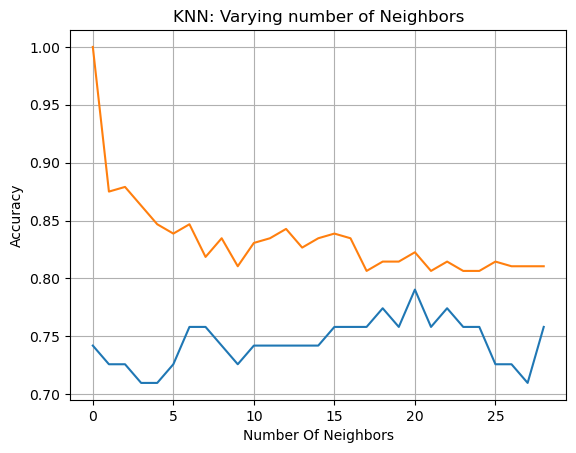

In [486]:
plt.plot(test_score, label="Test Accuracy")
plt.plot(train_score, label="Train Accuracy")
plt.xlabel("Number Of Neighbors")
plt.ylabel("Accuracy")
plt.title("KNN: Varying number of Neighbors")
plt.grid()

From the above plot we can say that n_neighbours = 20 has a better testing accuracy. <br>
Let us use this k-value and check if there is any performance improvement on the best model selected so far.

In [487]:
#Model 3
NNH4_2= KNeighborsClassifier(n_neighbors= 20 , leaf_size=1,p=2 )
NNH4_2.fit(X_train, y_train)

print("Score on Training Data: ",NNH4_2.score(X_train, y_train))
print("Score on Testing Data: ",NNH4_2.score(X_test, y_test))

predicted_labels4_2 = NNH4_2.predict(X_test)

print("Classification Report")
print(metrics.classification_report(y_test, predicted_labels4_2, labels=[0, 1,2]))

Score on Training Data:  0.8145161290322581
Score on Testing Data:  0.7580645161290323
Classification Report
              precision    recall  f1-score   support

           0       0.63      0.67      0.65        18
           1       0.67      0.73      0.70        11
           2       0.87      0.82      0.84        33

    accuracy                           0.76        62
   macro avg       0.72      0.74      0.73        62
weighted avg       0.77      0.76      0.76        62



In [488]:
print("Classification Report")
print(metrics.classification_report(y_test, predicted_labels4_1, labels=[0, 1,2]))

Classification Report
              precision    recall  f1-score   support

           0       0.60      0.67      0.63        18
           1       0.75      0.82      0.78        11
           2       0.87      0.79      0.83        33

    accuracy                           0.76        62
   macro avg       0.74      0.76      0.75        62
weighted avg       0.77      0.76      0.76        62



Comparing the Models with K=7(Model 2) and K=20 (Model 3).
- For Model 3, there is a very slight improvement in the precision and F1 score for Normal class
- Recall for Model 3 has a very slight improvement for Type S
- Precision, Recall and F1-score has reduced in Model 3 for Type H.

Considering that the improvements in score is not very significant when considering the reduction in scores for the Type_H class, we can conclude that Model 2 is a better model for prediction.

**C. Clearly state which parameters contributed most to improve model performance.**

In [489]:
NNH5 = KNeighborsClassifier(n_neighbors= 7)
NNH5.fit(X_train, y_train)

print("Score on Training Data: ",NNH5.score(X_train, y_train))
print("Score on Testing Data: ",NNH5.score(X_test, y_test))

predicted_labels5 = NNH5.predict(X_test)

print("Classification Report")
print(metrics.classification_report(y_test, predicted_labels5, labels=[0, 1,2]))

Score on Training Data:  0.8346774193548387
Score on Testing Data:  0.7580645161290323
Classification Report
              precision    recall  f1-score   support

           0       0.60      0.67      0.63        18
           1       0.75      0.82      0.78        11
           2       0.87      0.79      0.83        33

    accuracy                           0.76        62
   macro avg       0.74      0.76      0.75        62
weighted avg       0.77      0.76      0.76        62



In [490]:
NNH6 = KNeighborsClassifier(p=2 )
NNH6.fit(X_train, y_train)

print("Score on Training Data: ",NNH6.score(X_train, y_train))
print("Score on Testing Data: ",NNH6.score(X_test, y_test))
predicted_labels6 = NNH6.predict(X_test)
print("Classification Report")
print(metrics.classification_report(y_test, predicted_labels6, labels=[0, 1,2]))

Score on Training Data:  0.8467741935483871
Score on Testing Data:  0.7258064516129032
Classification Report
              precision    recall  f1-score   support

           0       0.57      0.67      0.62        18
           1       0.64      0.64      0.64        11
           2       0.87      0.79      0.83        33

    accuracy                           0.73        62
   macro avg       0.69      0.70      0.69        62
weighted avg       0.74      0.73      0.73        62



In [491]:
NNH7 = KNeighborsClassifier(leaf_size=1)
NNH7.fit(X_train, y_train)

print("Score on Training Data: ",NNH7.score(X_train, y_train))
print("Score on Testing Data: ",NNH7.score(X_test, y_test))

predicted_labels7 = NNH7.predict(X_test)

print("Classification Report")
print(metrics.classification_report(y_test, predicted_labels7, labels=[0, 1,2]))

Score on Training Data:  0.8467741935483871
Score on Testing Data:  0.7258064516129032
Classification Report
              precision    recall  f1-score   support

           0       0.57      0.67      0.62        18
           1       0.64      0.64      0.64        11
           2       0.87      0.79      0.83        33

    accuracy                           0.73        62
   macro avg       0.69      0.70      0.69        62
weighted avg       0.74      0.73      0.73        62



The hyper parameters that are tuned for the model are K=7, p=2 and leaf_size=1.<br>
creating 3 different models to understand the parameter that has contributed most to the improvement of the model performance. <br>

- There is a signigicant improvement in the precision and F1-score for Normal class when K=7
- Recall and F1-score for Type S is improved for the model when K=7
- There is a +11%, +18%, +14% increase in Precision, Recall and F1-score for Type H class when the K=7
- Precision, Recall and F1-score are identical for the models with p=2 and leaf_size=1

Without a doubt we can conclude that the K parameter has the most contribution to the model performance improvement.

## PART B

### Domain: Banking, Marketing

In [492]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from collections import Counter
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn import svm
from imblearn.over_sampling import SMOTENC
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

%matplotlib inline

### 1. Data Understanding and Preparation

**A. Read both the Datasets ‘Data1’ and ‘Data 2’ as DataFrame and store them into two separate variables.**

In [494]:
d1=pd.read_csv("Data1.csv")
d2=pd.read_csv("Data2.csv")

In [495]:
d1.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level
0,1,25,1,49,91107,4,1.6,1
1,2,45,19,34,90089,3,1.5,1
2,3,39,15,11,94720,1,1.0,1
3,4,35,9,100,94112,1,2.7,2
4,5,35,8,45,91330,4,1.0,2


In [496]:
d2.head()

,ID,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,0,1,0,0,0,NaN
1,2,0,1,0,0,0,NaN
2,3,0,0,0,0,0,NaN
3,4,0,0,0,0,0,NaN
4,5,0,0,0,0,1,NaN


**B. Print shape and Column Names and DataTypes of both the Dataframes.**

In [497]:
print("Shape of dataframe Data1 is ",d1.shape)
print("Shape of dataframe Data2 is ",d2.shape)

Shape of dataframe Data1 is  (5000, 8)
Shape of dataframe Data2 is  (5000, 7)


In [498]:
print("Column names of Dataframe Data1 is ")
print(d1.columns)
print("____"*25)
print("Column names of Dataframe Data2 is ")
print(d2.columns)

Column names of Dataframe Data1 is 
Index(['ID', 'Age', 'CustomerSince', 'HighestSpend', 'ZipCode', 'HiddenScore',
       'MonthlyAverageSpend', 'Level'],
      dtype='object')
____________________________________________________________________________________________________
Column names of Dataframe Data2 is 
Index(['ID', 'Mortgage', 'Security', 'FixedDepositAccount', 'InternetBanking',
       'CreditCard', 'LoanOnCard'],
      dtype='object')


In [499]:
print("Datatype of Dataframe Data1 is")
print(d1.info())

Datatype of Dataframe Data1 is
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   int64  
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 312.6 KB
None


In [500]:
print("Datatype of Dataframe Data2 is")
print(d2.info())

Datatype of Dataframe Data2 is
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Mortgage             5000 non-null   int64  
 2   Security             5000 non-null   int64  
 3   FixedDepositAccount  5000 non-null   int64  
 4   InternetBanking      5000 non-null   int64  
 5   CreditCard           5000 non-null   int64  
 6   LoanOnCard           4980 non-null   float64
dtypes: float64(1), int64(6)
memory usage: 273.6 KB
None


**C. Merge both the Dataframes on ‘ID’ feature to form a single DataFrame**

In [501]:
d12 = pd.merge(d1, d2, left_index=True, right_index=True)

In [502]:
d12.head()

,ID_x,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,ID_y,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,25,1,49,91107,4,1.6,1,1,0,1,0,0,0,NaN
1,2,45,19,34,90089,3,1.5,1,2,0,1,0,0,0,NaN
2,3,39,15,11,94720,1,1.0,1,3,0,0,0,0,0,NaN
3,4,35,9,100,94112,1,2.7,2,4,0,0,0,0,0,NaN
4,5,35,8,45,91330,4,1.0,2,5,0,0,0,0,1,NaN


In [503]:
d12.shape

(5000, 15)

In [504]:
d12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_x                 5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   int64  
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   int64  
 8   ID_y                 5000 non-null   int64  
 9   Mortgage             5000 non-null   int64  
 10  Security             5000 non-null   int64  
 11  FixedDepositAccount  5000 non-null   int64  
 12  InternetBanking      5000 non-null   int64  
 13  CreditCard           5000 non-null   int64  
 14  LoanOnCard           4980 non-null   float64
dtypes: float64(2), int64(13)
memory usage:

Let us check if the dataframes are copied correctly based on the ID values

In [505]:
d12[d12["ID_x"]!=d12["ID_y"]]

,ID_x,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,ID_y,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard


Since we have 2 ID columns, we can drop any one of the ID column

In [506]:
d12.drop("ID_y", axis=1, inplace=True)

In [507]:
d12.columns

Index(['ID_x', 'Age', 'CustomerSince', 'HighestSpend', 'ZipCode',
       'HiddenScore', 'MonthlyAverageSpend', 'Level', 'Mortgage', 'Security',
       'FixedDepositAccount', 'InternetBanking', 'CreditCard', 'LoanOnCard'],
      dtype='object')

In [508]:
d12=d12.rename(columns={"ID_x":"ID"})

In [509]:
d12.columns

Index(['ID', 'Age', 'CustomerSince', 'HighestSpend', 'ZipCode', 'HiddenScore',
       'MonthlyAverageSpend', 'Level', 'Mortgage', 'Security',
       'FixedDepositAccount', 'InternetBanking', 'CreditCard', 'LoanOnCard'],
      dtype='object')

**D. Change Datatype of below features to ‘Object’** <br>
 **‘CreditCard’, ‘InternetBanking’, ‘FixedDepositAccount’, ‘Security’, ‘Level’, ‘HiddenScore’.**

In [510]:
d12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   int64  
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   int64  
 8   Mortgage             5000 non-null   int64  
 9   Security             5000 non-null   int64  
 10  FixedDepositAccount  5000 non-null   int64  
 11  InternetBanking      5000 non-null   int64  
 12  CreditCard           5000 non-null   int64  
 13  LoanOnCard           4980 non-null   float64
dtypes: float64(2), int64(12)
memory usage: 547.0 KB


In [511]:
col=["CreditCard", "InternetBanking", "FixedDepositAccount", "Security", "Level", "HiddenScore"]
for i in col:
    d12[i]=d12[i].astype(object)

In [512]:
d12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   5000 non-null   int64  
 1   Age                  5000 non-null   int64  
 2   CustomerSince        5000 non-null   int64  
 3   HighestSpend         5000 non-null   int64  
 4   ZipCode              5000 non-null   int64  
 5   HiddenScore          5000 non-null   object 
 6   MonthlyAverageSpend  5000 non-null   float64
 7   Level                5000 non-null   object 
 8   Mortgage             5000 non-null   int64  
 9   Security             5000 non-null   object 
 10  FixedDepositAccount  5000 non-null   object 
 11  InternetBanking      5000 non-null   object 
 12  CreditCard           5000 non-null   object 
 13  LoanOnCard           4980 non-null   float64
dtypes: float64(2), int64(6), object(6)
memory usage: 547.0+ KB


### 2. Data Exploration and Analysis

**A. Visualize distribution of Target variable ‘LoanOnCard’ and clearly share insights.**

In [513]:
d12["LoanOnCard"].unique()

array([nan,  1.,  0.])

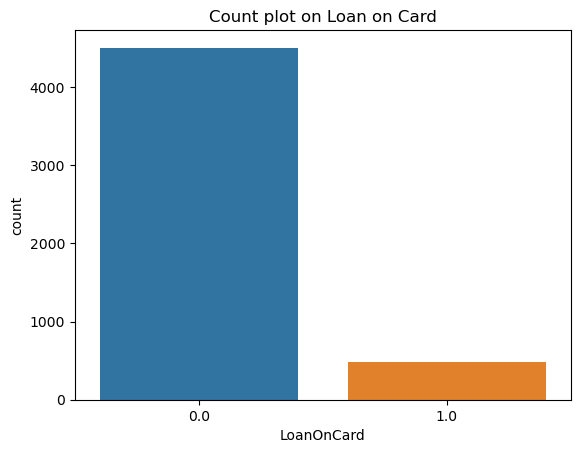

In [514]:
sns.countplot(d12,x="LoanOnCard")
plt.title("Count plot on Loan on Card")
plt.show()

Observations on the LoanOnCard variable
 - There are very few customer who has a loan on the credit card
 - Most of the customers in the dataset does not have a loan on the credit card
 - Data set is highly imbalanced because the number of datapoints without loan is almost 4500 and the number of datapoints with loan is as less than 500

**B. Check the percentage of missing values and impute if required.**

In [515]:
def missper():
    for i in d12.columns:
        print("% of missing values in column ",i,"is", (d12[i].isnull().sum()/d12.shape[0]))
missper()

% of missing values in column  ID is 0.0
% of missing values in column  Age is 0.0
% of missing values in column  CustomerSince is 0.0
% of missing values in column  HighestSpend is 0.0
% of missing values in column  ZipCode is 0.0
% of missing values in column  HiddenScore is 0.0
% of missing values in column  MonthlyAverageSpend is 0.0
% of missing values in column  Level is 0.0
% of missing values in column  Mortgage is 0.0
% of missing values in column  Security is 0.0
% of missing values in column  FixedDepositAccount is 0.0
% of missing values in column  InternetBanking is 0.0
% of missing values in column  CreditCard is 0.0
% of missing values in column  LoanOnCard is 0.004


Except for the column LoanOnCard all the other columns have no missing values.<br>
LoanOnCard has .4% of missing values which is very less compared to the total number of datapoints.<br>

Let us find out the different values and the datatype of the LoanOnCard column

In [516]:
print("Unique values in the Loan On Card column is ",d12["LoanOnCard"].unique())
print("Datatype of the Loan On Card column is", d12["LoanOnCard"].dtype)

Unique values in the Loan On Card column is  [nan  1.  0.]
Datatype of the Loan On Card column is float64


The column LoanOnCard has only 2 unique values 0 and 1 so we can consider this column to be of object datatype.

In [517]:
#Converting the datatype of LoanOnCard column to Object
d12["LoanOnCard"]=d12["LoanOnCard"].astype("category")

LoanOnCard is a categorical variable and for categorical variables, we need to treat the missing values by replacing the null values with the mode. This might not be an advisable action to perform since the missing values are the target variable and we might be defining a behaviour in the model. Instead we can drop the null values with  We have observed earlier that the dataset is highly imbalanced with most of the data have LoanOnCard = 0, so dropping the rows which will otherwise be replaced with target value as 0 should not have much effect on the dataset

In [518]:
d12.dropna(subset=["LoanOnCard"], inplace=True)

In [519]:
missper()

% of missing values in column  ID is 0.0
% of missing values in column  Age is 0.0
% of missing values in column  CustomerSince is 0.0
% of missing values in column  HighestSpend is 0.0
% of missing values in column  ZipCode is 0.0
% of missing values in column  HiddenScore is 0.0
% of missing values in column  MonthlyAverageSpend is 0.0
% of missing values in column  Level is 0.0
% of missing values in column  Mortgage is 0.0
% of missing values in column  Security is 0.0
% of missing values in column  FixedDepositAccount is 0.0
% of missing values in column  InternetBanking is 0.0
% of missing values in column  CreditCard is 0.0
% of missing values in column  LoanOnCard is 0.0


In [520]:
d12.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4980 entries, 9 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   4980 non-null   int64   
 1   Age                  4980 non-null   int64   
 2   CustomerSince        4980 non-null   int64   
 3   HighestSpend         4980 non-null   int64   
 4   ZipCode              4980 non-null   int64   
 5   HiddenScore          4980 non-null   object  
 6   MonthlyAverageSpend  4980 non-null   float64 
 7   Level                4980 non-null   object  
 8   Mortgage             4980 non-null   int64   
 9   Security             4980 non-null   object  
 10  FixedDepositAccount  4980 non-null   object  
 11  InternetBanking      4980 non-null   object  
 12  CreditCard           4980 non-null   object  
 13  LoanOnCard           4980 non-null   category
dtypes: category(1), float64(1), int64(6), object(6)
memory usage: 549.7+ KB


**C. Check for unexpected values in each categorical variable and impute with best suitable value.**

In [521]:
col.append("LoanOnCard")
col

['CreditCard',
 'InternetBanking',
 'FixedDepositAccount',
 'Security',
 'Level',
 'HiddenScore',
 'LoanOnCard']

In [522]:
for i in col:
    print(i)
    print(d12[i].unique())
    print("__"*25)

CreditCard
[0 1]
__________________________________________________
InternetBanking
[0 1]
__________________________________________________
FixedDepositAccount
[0 1]
__________________________________________________
Security
[0 1]
__________________________________________________
Level
[3 2 1]
__________________________________________________
HiddenScore
[1 4 3 2]
__________________________________________________
LoanOnCard
[1.0, 0.0]
Categories (2, float64): [0.0, 1.0]
__________________________________________________


C:\Users\imays\AppData\Local\Temp\ipykernel_28288\2616176972.py:3: FutureWarning: Index.ravel returning ndarray is deprecated; in a future version this will return a view on self.
  print(d12[i].unique())


Converting the values in the LoanOnCard column from 0. and 1. to 0 and 1 respectively.

In [523]:
d12["LoanOnCard"]=d12["LoanOnCard"].astype(int)

In [524]:
d12["LoanOnCard"]=d12["LoanOnCard"].astype("category")

In [525]:
d12.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4980 entries, 9 to 4999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   ID                   4980 non-null   int64   
 1   Age                  4980 non-null   int64   
 2   CustomerSince        4980 non-null   int64   
 3   HighestSpend         4980 non-null   int64   
 4   ZipCode              4980 non-null   int64   
 5   HiddenScore          4980 non-null   object  
 6   MonthlyAverageSpend  4980 non-null   float64 
 7   Level                4980 non-null   object  
 8   Mortgage             4980 non-null   int64   
 9   Security             4980 non-null   object  
 10  FixedDepositAccount  4980 non-null   object  
 11  InternetBanking      4980 non-null   object  
 12  CreditCard           4980 non-null   object  
 13  LoanOnCard           4980 non-null   category
dtypes: category(1), float64(1), int64(6), object(6)
memory usage: 549.7+ KB


### 3. Data Preparation and model building

**A. Split data into X and Y.**

In [526]:
#Before splitting the data points into training and testing datasets,
#let us drop columns like id and postcode which is not a deciding factor on the LoanOnCard

d12.drop(columns=["ID","ZipCode"],inplace=True)

In [527]:
d12.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4980 entries, 9 to 4999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Age                  4980 non-null   int64   
 1   CustomerSince        4980 non-null   int64   
 2   HighestSpend         4980 non-null   int64   
 3   HiddenScore          4980 non-null   object  
 4   MonthlyAverageSpend  4980 non-null   float64 
 5   Level                4980 non-null   object  
 6   Mortgage             4980 non-null   int64   
 7   Security             4980 non-null   object  
 8   FixedDepositAccount  4980 non-null   object  
 9   InternetBanking      4980 non-null   object  
 10  CreditCard           4980 non-null   object  
 11  LoanOnCard           4980 non-null   category
dtypes: category(1), float64(1), int64(4), object(6)
memory usage: 471.9+ KB


In [528]:
#Splitting data into X and Y
X=d12.drop(columns=["LoanOnCard"],inplace=False)
y=d12["LoanOnCard"]

In [529]:
X.columns

Index(['Age', 'CustomerSince', 'HighestSpend', 'HiddenScore',
       'MonthlyAverageSpend', 'Level', 'Mortgage', 'Security',
       'FixedDepositAccount', 'InternetBanking', 'CreditCard'],
      dtype='object')

In [530]:
y.unique()

[1, 0]
Categories (2, int64): [0, 1]

**B. Split data into train and test. Keep 25% data reserved for testing.**

In [545]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=1)
print("X_train",X_train.shape)
print("X_test",X_test.shape)
print("y_train",y_train.shape)
print("y_test",y_test.shape)

X_train (3735, 11)
X_test (1245, 11)
y_train (3735,)
y_test (1245,)


**C. Train a Supervised Learning Classification base model - Logistic Regression.**

In [546]:
# Fit the model on train
model = LogisticRegression(solver="liblinear")
model.fit(X_train, y_train)
#predict on test
y_predict = model.predict(X_test)


coef_df = pd.DataFrame(model.coef_)
coef_df['intercept'] = model.intercept_
print(coef_df)

         0         1         2         3         4        5         6  \
0 -0.41497  0.415445  0.050564  0.580127  0.115391  1.71864  0.000397   

          7         8         9        10  intercept  
0 -0.669608  3.233102 -0.599966 -0.844486  -2.132368  


**D. Print evaluation metrics for the model and clearly share insights.**

In [547]:
model_score_test = model.score(X_test, y_test)
model_score_train = model.score(X_train,y_train)
print("Model Score in testing data: ",model_score_test)
print("Model score in training data: ",model_score_train)

Model Score in testing data:  0.9477911646586346
Model score in training data:  0.951004016064257


<Axes: >

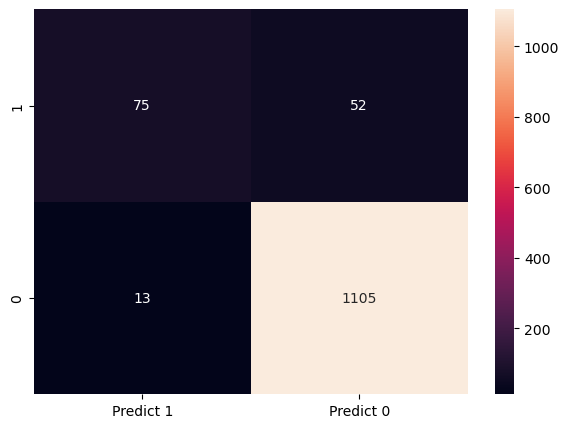

In [548]:
cm=metrics.confusion_matrix(y_test, y_predict, labels=[1, 0])

df_cm = pd.DataFrame(cm, index = [i for i in ["1","0"]],
                  columns = [i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True,fmt='g')

Confusion Matrix inferences
 - True Positives (TP): We have correctly predicted that 75 has loan on credit card
 - True Negatives (TN): we have correctly predicted that 1105 has no loan on credit card
 - False Positives (FP): we incorrectly predicted that 13 have loan on credit card(a "Type I error")
 - False Negatives (FN): we incorrectly predicted that 52 have no loan on credit card (a "Type II error")

In [537]:
print("Classification Report")
print(metrics.classification_report(y_test, y_predict, labels=[1, 0]))

Classification Report
              precision    recall  f1-score   support

           1       0.85      0.59      0.70       127
           0       0.96      0.99      0.97      1118

    accuracy                           0.95      1245
   macro avg       0.90      0.79      0.83      1245
weighted avg       0.94      0.95      0.94      1245



Inferences of the report
 - Since there is only very less data to train for the value of 1, we can see that the recall and f1-score for value 1 is very much less than that of value 0.
 - The accuracy for the model is 0.95
 - Precision for both values 1 and 0 are greater than 0.85
 - Precisiom, recall and f1-score for value 0 is very high and is greater than or equal to 0.96

**E. Balance the data using the right balancing technique.**
 - **i. Check distribution of the target variable**
 - **ii. Say output is class A : 20% and class B : 80%**
 - **iii. Here you need to balance the target variable as 50:50.**
 - **iv. Try appropriate method to achieve the same.**

Let us balance the data using the different balancing techniques
 - SMOTE_NC
 - Random Undersampling
 - Random Oversampling

In [549]:
#SMOTE
counter = Counter(y_train)
print("Before ",counter)
#oversampling the train dataset using SMOTE

smt=SMOTENC(categorical_features=[3,5,7,8,9,10],random_state=1)
X_train_smt,y_train_smt=smt.fit_resample(X_train,y_train)

counter = Counter(y_train_smt)
print("After ",counter)

Before  Counter({0: 3382, 1: 353})
After  Counter({0: 3382, 1: 3382})


In [550]:
#Random Under Sampling
rus = RandomUnderSampler(random_state=42, replacement=True)# fit predictor and target variable
x_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print('original dataset shape:', Counter(y_train))
print('Resample dataset shape', Counter(y_train_rus))

original dataset shape: Counter({0: 3382, 1: 353})
Resample dataset shape Counter({0: 353, 1: 353})


In [551]:
#Random Over Sampling

ros = RandomOverSampler(random_state=42)
x_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print('Original dataset shape', Counter(y_train))
print('Resample dataset shape', Counter(y_train_ros))

Original dataset shape Counter({0: 3382, 1: 353})
Resample dataset shape Counter({0: 3382, 1: 3382})


**F. Again train the same previous model on balanced data.**

Training the Logistic regression model using the dataset balanced using SMOTE balancing technique

In [552]:
model_bal_smt = LogisticRegression(solver="liblinear")
model_bal_smt.fit(X_train_smt, y_train_smt)
#predict on test
y_predict_smt = model_bal_smt.predict(X_test)

In [553]:
model_score_smt_test = model_bal_smt.score(X_test, y_test)
model_score_smt_train=model_bal_smt.score(X_train_smt, y_train_smt)
print("Model Score in testing data after balancing the target variable using SMOTE balancing technique ",model_score_smt_test)
print("Model Score in training data after balancing the target variable using SMOTE balancing technique ",model_score_smt_train)

Model Score in testing data after balancing the target variable using SMOTE balancing technique  0.8963855421686747
Model Score in training data after balancing the target variable using SMOTE balancing technique  0.9055292726197516


<Axes: >

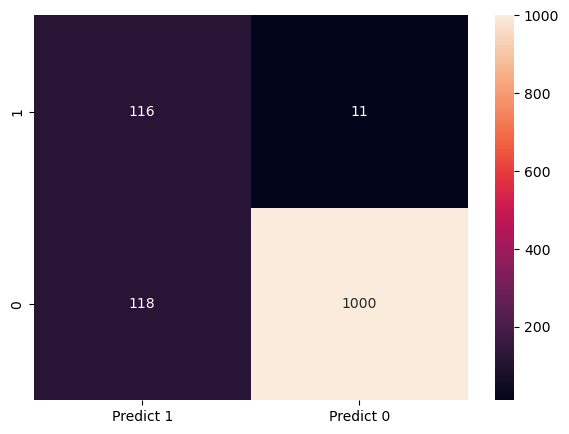

In [554]:
cm_bal_smt=metrics.confusion_matrix(y_test, y_predict_smt, labels=[1, 0])

df_cm_smt = pd.DataFrame(cm_bal_smt, index = [i for i in ["1","0"]],
                  columns = [i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm_smt, annot=True,fmt='g')

In [555]:
print("Classification Report for target value balanced using SMOTE")
print(metrics.classification_report(y_test, y_predict_smt, labels=[1, 0]))

Classification Report for target value balanced using SMOTE
              precision    recall  f1-score   support

           1       0.50      0.91      0.64       127
           0       0.99      0.89      0.94      1118

    accuracy                           0.90      1245
   macro avg       0.74      0.90      0.79      1245
weighted avg       0.94      0.90      0.91      1245



- Precision and Recall are less for the value of 1.
- Recall for the value of 1 is 0.84
- Precision, Recall and F1-score are greater than 0.89 for with precision = 0.99 for the value of 0.
- Accuracy is equal to 0.90

**Training the Logistic regression model using the dataset balanced using Random Undersampling balancing technique**

In [556]:
model_bal_rus = LogisticRegression(solver="liblinear")
model_bal_rus.fit(x_train_rus, y_train_rus)
#predict on test
y_predict_rus = model_bal_rus.predict(X_test)

In [557]:
model_score_rus_test= model_bal_rus.score(X_test, y_test)
model_score_rus_train= model_bal_rus.score(x_train_rus, y_train_rus)
print("Model Score using testing data after balancing the target variable using Random Under Sampling balancing technique ",model_score_rus_test)
print("Model Score using training data after balancing the target variable using Random Under Sampling balancing technique ",model_score_rus_train)

Model Score using testing data after balancing the target variable using Random Under Sampling balancing technique  0.8779116465863454
Model Score using training data after balancing the target variable using Random Under Sampling balancing technique  0.9050991501416431


In [558]:
cm_bal_rus=metrics.confusion_matrix(y_test, y_predict_rus, labels=[1, 0])

<Axes: >

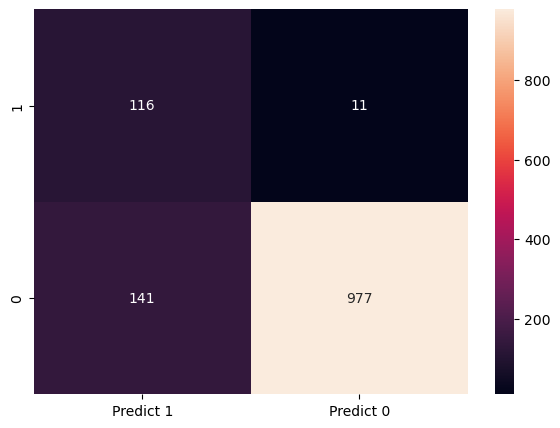

In [559]:
df_cm_rus = pd.DataFrame(cm_bal_rus, index = [i for i in ["1","0"]],
                  columns = [i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm_rus, annot=True,fmt='g')

In [560]:
print("Classification Report for target value balanced using Random Under Sampling")
print(metrics.classification_report(y_test, y_predict_rus, labels=[1, 0]))

Classification Report for target value balanced using Random Under Sampling
              precision    recall  f1-score   support

           1       0.45      0.91      0.60       127
           0       0.99      0.87      0.93      1118

    accuracy                           0.88      1245
   macro avg       0.72      0.89      0.77      1245
weighted avg       0.93      0.88      0.89      1245



- Precision and F1-score for the value of 1 is less.
- Precision and F1-score is high for the value of 0 with values greater than or equal to 0.0.87
- Recall for both the values 0 and 1 are high with values 0.90 and 0.86 respectively.
- Accuracy for the model is 0.89

**Training the Logistic regression model using the dataset balanced using Random Undersampling balancing technique**

In [561]:
model_bal_ros = LogisticRegression(solver="liblinear")
model_bal_ros.fit(x_train_ros, y_train_ros)
#predict on test
y_predict_ros = model_bal_ros.predict(X_test)

In [562]:
model_score_ros_train = model_bal_ros.score(X_test, y_test)
model_score_ros_test = model_bal_ros.score(x_train_ros, y_train_ros)
print("Model Score for the testing data after balancing the target variable using Random Over Sampling balancing technique ",model_score_ros_test)
print("Model Score for the training data after balancing the target variable using Random Over Sampling balancing technique ",model_score_ros_train)

Model Score for the testing data after balancing the target variable using Random Over Sampling balancing technique  0.8935541099940864
Model Score for the training data after balancing the target variable using Random Over Sampling balancing technique  0.891566265060241


<Axes: >

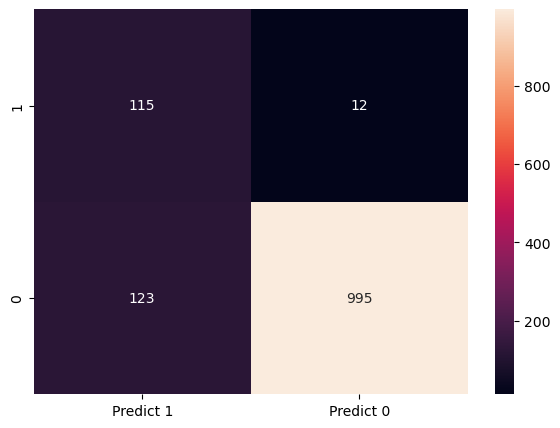

In [563]:
cm_bal_ros=metrics.confusion_matrix(y_test, y_predict_ros, labels=[1, 0])

df_cm_ros = pd.DataFrame(cm_bal_ros, index = [i for i in ["1","0"]],
                  columns = [i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm_ros, annot=True,fmt='g')

In [564]:
print("Classification Report for target value balanced using Random Over Sampling")
print("__"*38)
print(metrics.classification_report(y_test, y_predict_ros, labels=[1, 0]))

Classification Report for target value balanced using Random Over Sampling
____________________________________________________________________________
              precision    recall  f1-score   support

           1       0.48      0.91      0.63       127
           0       0.99      0.89      0.94      1118

    accuracy                           0.89      1245
   macro avg       0.74      0.90      0.78      1245
weighted avg       0.94      0.89      0.91      1245



- Precision and F1 score for the value of 1 is less.
 - Precision and F1 score for the value of 0 is high with values in the range of 0.94
 - Recall is having a high value for both the 0 and 1 values
 - Accuracy is 0.89

**G. Print evaluation metrics and clearly share differences observed.**

In [565]:
print("Classification Report for target value balanced using Random Over Sampling")
print("__"*38)
print(metrics.classification_report(y_test, y_predict_ros, labels=[1, 0]))


print("Model Score")
print("Testing data: ",model_score_ros_test)
print("Training data: ",model_score_ros_train)

Classification Report for target value balanced using Random Over Sampling
____________________________________________________________________________
              precision    recall  f1-score   support

           1       0.48      0.91      0.63       127
           0       0.99      0.89      0.94      1118

    accuracy                           0.89      1245
   macro avg       0.74      0.90      0.78      1245
weighted avg       0.94      0.89      0.91      1245

Model Score
Testing data:  0.8935541099940864
Training data:  0.891566265060241


In [566]:
print("Classification Report for target value balanced using Random Under Sampling")
print("__"*38)
print(metrics.classification_report(y_test, y_predict_rus, labels=[1, 0]))

print("Model Score")
print("Testing data: ",model_score_rus_test)
print("Training data: ",model_score_rus_train)

Classification Report for target value balanced using Random Under Sampling
____________________________________________________________________________
              precision    recall  f1-score   support

           1       0.45      0.91      0.60       127
           0       0.99      0.87      0.93      1118

    accuracy                           0.88      1245
   macro avg       0.72      0.89      0.77      1245
weighted avg       0.93      0.88      0.89      1245

Model Score
Testing data:  0.8779116465863454
Training data:  0.9050991501416431


In [567]:
print("Classification Report for target value balanced using SMOTE")
print("__"*30)
print(metrics.classification_report(y_test, y_predict_smt, labels=[1, 0]))

print("Model Score")
print("Testing data: ",model_score_smt_test)
print("Training data: ",model_score_smt_train)

Classification Report for target value balanced using SMOTE
____________________________________________________________
              precision    recall  f1-score   support

           1       0.50      0.91      0.64       127
           0       0.99      0.89      0.94      1118

    accuracy                           0.90      1245
   macro avg       0.74      0.90      0.79      1245
weighted avg       0.94      0.90      0.91      1245

Model Score
Testing data:  0.8963855421686747
Training data:  0.9055292726197516


**Inferences on the 3 balancing techniques:**
- Precision for the value of 1 is higher for SMOTE
- F1-score for value 1 is higher for SMOTE

When comparing the 3 balancing techniques that was implemented, we can observe improvements in the precision and f1-score for the value of 1 when using SMOTE_NC balancing technique, hence we shall consider the SMOTE_NC training data set.

### 4. Performance Improvement

**A. Train a base model each for SVM, KNN.**

In [568]:
# KNN Modeling
KNN_Model = KNeighborsClassifier()

In [569]:
#For the KNN Model, the X parameters needs to be scaled
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4980 entries, 9 to 4999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  4980 non-null   int64  
 1   CustomerSince        4980 non-null   int64  
 2   HighestSpend         4980 non-null   int64  
 3   HiddenScore          4980 non-null   object 
 4   MonthlyAverageSpend  4980 non-null   float64
 5   Level                4980 non-null   object 
 6   Mortgage             4980 non-null   int64  
 7   Security             4980 non-null   object 
 8   FixedDepositAccount  4980 non-null   object 
 9   InternetBanking      4980 non-null   object 
 10  CreditCard           4980 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 466.9+ KB


Scaling the X_train_smt before applying the KNN modeling

In [570]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

num_cols=["Age","CustomerSince","HighestSpend","MonthlyAverageSpend","Mortgage"]
for i in num_cols:
    X_train_smt[i] = std_scaler.fit_transform(X_train_smt[[i]])

In [571]:
X_train_smt.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6764.0,-2.311050e-17,1.000074,-1.939075,-0.868702,-0.065922,0.826055,1.985626
CustomerSince,6764.0,5.252386e-17,1.000074,-2.004481,-0.845255,-0.042714,0.848999,2.097396
HighestSpend,6764.0,-6.723054e-17,1.000074,-1.821111,-0.886078,0.123758,0.871784,2.218232
MonthlyAverageSpend,6764.0,0.000000e+00,1.000074,-1.384481,-0.806154,-0.179633,0.640722,3.434912
Mortgage,6764.0,-6.723054e-17,1.000074,-0.567872,-0.567872,-0.567872,0.324971,4.140542


In [572]:
KNN_Model.fit(X_train_smt,y_train_smt)

KNeighborsClassifier()

Scaling the X_test

In [573]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

num_cols=["Age","CustomerSince","HighestSpend","MonthlyAverageSpend","Mortgage"]
for i in num_cols:
    X_test[i] = std_scaler.fit_transform(X_test[[i]])

In [574]:
 X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1245.0,2.197261e-16,1.000402,-1.954362,-0.837160,0.022227,0.881613,1.826938
CustomerSince,1245.0,-5.421812e-17,1.000402,-1.932620,-0.902018,0.042700,0.901535,1.932137
HighestSpend,1245.0,-6.919944e-17,1.000402,-1.478109,-0.780162,-0.234891,0.572110,2.775004
MonthlyAverageSpend,1245.0,7.419322e-17,1.000402,-1.145041,-0.731320,-0.199393,0.391637,4.056021
Mortgage,1245.0,-5.707171e-17,1.000402,-0.553413,-0.553413,-0.553413,0.425697,5.482849


In [575]:
y_pred_KNN = KNN_Model.predict(X_test)

In [576]:
print("KNN Model score with test data: ",KNN_Model.score(X_test, y_test))
print("KNN Model score with training data: ",KNN_Model.score(X_train_smt,y_train_smt))

KNN Model score with test data:  0.8257028112449799
KNN Model score with training data:  0.9843287995269071


Confusion Matrix for the KNN Model


<Axes: >

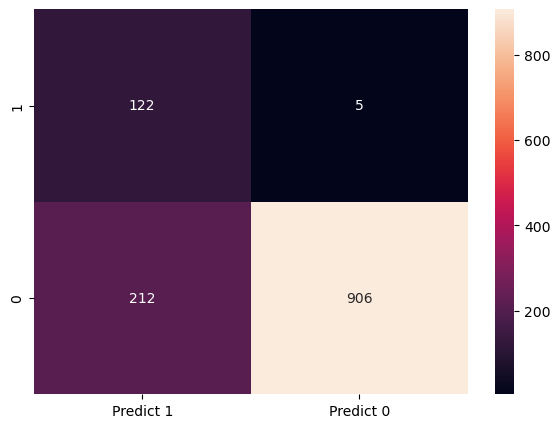

In [577]:
print("Confusion Matrix for the KNN Model")
cm_knn=metrics.confusion_matrix(y_test, y_pred_KNN, labels=[1, 0])

df_cm_knn =pd.DataFrame(cm_knn, index = [i for i in ["1","0"]],
                  columns = [i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize = (7,5))
sns.heatmap(df_cm_knn, annot=True,fmt='g')

In [578]:
print("Classification Report for KNN Model")
print("__"*30)
print(metrics.classification_report(y_test, y_pred_KNN, labels=[1, 0]))

Classification Report for KNN Model
____________________________________________________________
              precision    recall  f1-score   support

           1       0.37      0.96      0.53       127
           0       0.99      0.81      0.89      1118

    accuracy                           0.83      1245
   macro avg       0.68      0.89      0.71      1245
weighted avg       0.93      0.83      0.86      1245



In [579]:
#SVM Modeling
SVM_Model = svm.SVC()
SVM_Model.fit(X_train_smt,y_train_smt)

SVC()

In [580]:
y_pred_SVM = SVM_Model.predict(X_test)

In [581]:
print("SVM Model score using test data: ",SVM_Model.score(X_test,y_test))
print("SVM Model score using training data: ", SVM_Model.score(X_train_smt,y_train_smt))

SVM Model score using test data:  0.8176706827309237
SVM Model score using training data:  0.969692489651094


Confusion Matrix for the SVM Model


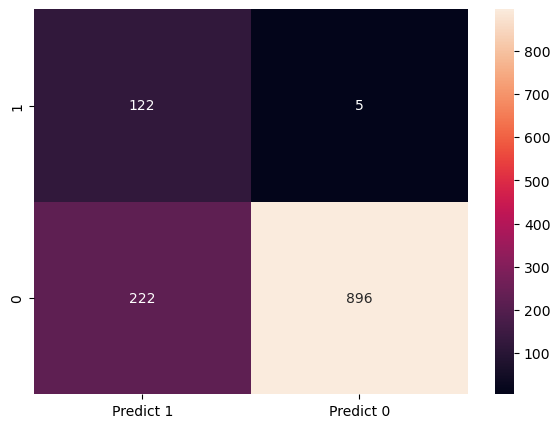

In [582]:
print("Confusion Matrix for the SVM Model")
cm_svm = metrics.confusion_matrix(y_test,y_pred_SVM,labels=[1,0])

df_cm_svm = pd.DataFrame(cm_svm,index=[i for i in ["1","0"]],
                        columns=[i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize=(7,5))
sns.heatmap(df_cm_svm,annot=True,fmt="g");

In [583]:
print("Classification Report for SVM Model")
print("__"*30)
print(metrics.classification_report(y_test,y_pred_SVM,labels=[1,0]))

Classification Report for SVM Model
____________________________________________________________
              precision    recall  f1-score   support

           1       0.35      0.96      0.52       127
           0       0.99      0.80      0.89      1118

    accuracy                           0.82      1245
   macro avg       0.67      0.88      0.70      1245
weighted avg       0.93      0.82      0.85      1245



In [584]:
print("Classification Report for KNN Model")
print("__"*30)
print(metrics.classification_report(y_test, y_pred_KNN, labels=[1, 0]))

Classification Report for KNN Model
____________________________________________________________
              precision    recall  f1-score   support

           1       0.37      0.96      0.53       127
           0       0.99      0.81      0.89      1118

    accuracy                           0.83      1245
   macro avg       0.68      0.89      0.71      1245
weighted avg       0.93      0.83      0.86      1245



Inferences on the performance of the KNN and SVM Model
- Accuracy for the KNN model is slightly better than the SVM Model
- Precision is very less for the SVM Model.
- Precision for the KNN Model is slightly better than the SVM Model
- F1-score is better for the KNN Model

Overall when comparing the 2 models, KNN has better performance scores than the SVM Model.

**B. Tune parameters for each of the models wherever required and finalize a model.**

In [164]:
#Tuning the parameters for the KNN Model
n_neighbors = list(range(3,20))
#weights = ["uniform", "distance"]
#algorithm = ["ball_tree", "kd_tree", "brute"]
leaf_size = list(range(1,20))
p=[1,2]
#Convert to dictionary
#hyperparameters = dict(n_neighbors=n_neighbors,weights=weights,algorithm=algorithm,leaf_size=leaf_size, p=p)
hyperparameters = dict(n_neighbors=n_neighbors,leaf_size=leaf_size, p=p)
#Create new KNN object
KNN_Model2 = KNeighborsClassifier()
#Use GridSearch
clf = GridSearchCV(KNN_Model2, hyperparameters, cv=10)
#Fit the model
best_model = clf.fit(X_train_smt,y_train_smt)
print("The value of best Hyperparameters")
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])
#print('Best weights:', best_model.best_estimator_.get_params()['weights'])
#print('Best algorithm:', best_model.best_estimator_.get_params()['algorithm'])
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])

The value of best Hyperparameters
Best n_neighbors: 6
Best leaf_size: 1
Best p: 1


In [585]:
KNN_Model_tune1 = KNeighborsClassifier(n_neighbors=6,leaf_size=1,p=1)

In [586]:
KNN_Model_tune1.fit(X_train_smt,y_train_smt)

KNeighborsClassifier(leaf_size=1, n_neighbors=6, p=1)

In [587]:
y_pred_KNN_tune1 = KNN_Model.predict(X_test)

In [588]:
print("KNN Model score with test data: ",KNN_Model_tune1.score(X_test, y_test))
print("KNN Model score with training data: ",KNN_Model_tune1.score(X_train_smt,y_train_smt))

KNN Model score with test data:  0.8417670682730923
KNN Model score with training data:  0.9866942637492608


In [589]:
print("Classification Report for KNN Model after tuning the parameters")
print("__"*30)
print(metrics.classification_report(y_test, y_pred_KNN_tune1, labels=[1, 0]))

Classification Report for KNN Model after tuning the parameters
____________________________________________________________
              precision    recall  f1-score   support

           1       0.37      0.96      0.53       127
           0       0.99      0.81      0.89      1118

    accuracy                           0.83      1245
   macro avg       0.68      0.89      0.71      1245
weighted avg       0.93      0.83      0.86      1245



In [590]:
#Checking if there could be a better K value
test_score =[]
train_score =[]
for k in range(1,30):
    KNN_Model_tune2 = KNeighborsClassifier(n_neighbors = k,leaf_size=1,p=1 )
    KNN_Model_tune2.fit(X_train_smt,y_train_smt)
    train_score.append(KNN_Model_tune2.score(X_train_smt,y_train_smt))
    test_score.append(KNN_Model_tune2.score(X_test,y_test))

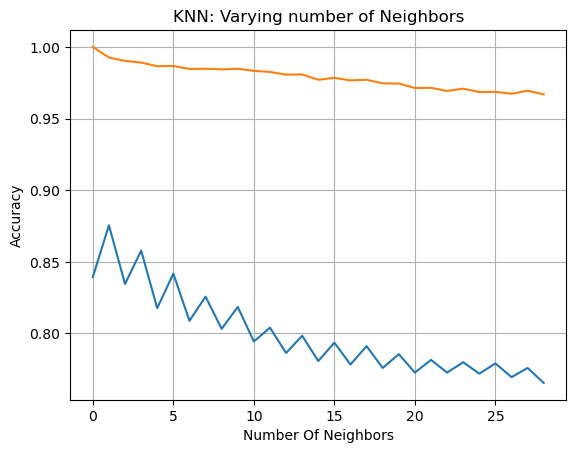

In [591]:
plt.plot(test_score, label="Test Accuracy")
plt.plot(train_score, label="Train Accuracy")
plt.xlabel("Number Of Neighbors")
plt.ylabel("Accuracy")
plt.title("KNN: Varying number of Neighbors")
plt.grid()

K=6 itself looks like a better fit for the model.

In [171]:
#Tuning parameters for the SVM Model
SVM_Param = {'C': [0.1,1, 10], 'gamma': [1,0.1,0.25]}
grid = GridSearchCV(svm.SVC(),SVM_Param,refit=True,verbose=2)
SVM_Modeltune=grid.fit(X_train_smt,y_train_smt)

best_model = clf.fit(X_train_smt,y_train_smt)
print("The value of best Hyperparameters")
print('Best C :', SVM_Modeltune.best_estimator_.get_params()['C'])
print('Best gamma :', SVM_Modeltune.best_estimator_.get_params()['gamma'])

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END .....................................C=0.1, gamma=1; total time=   2.1s
[CV] END .....................................C=0.1, gamma=1; total time=   2.2s
[CV] END .....................................C=0.1, gamma=1; total time=   2.2s
[CV] END .....................................C=0.1, gamma=1; total time=   2.2s
[CV] END .....................................C=0.1, gamma=1; total time=   2.2s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ..................................C=0.1, gamma=0.25; total time=   0.9s
[CV] END ..................................C=0.1,

SVM Modelling using the tuned hyperparameters

In [594]:
SVM_Model_tune1 = svm.SVC(C=10,gamma=0.25)
SVM_Model_tune1.fit(X_train_smt,y_train_smt)

SVC(C=10, gamma=0.25)

In [595]:
y_pred_SVM_tune1 = SVM_Model_tune1.predict(X_test)

In [596]:
print("SVM Model score using test data: ",SVM_Model_tune1.score(X_test,y_test))
print("SVM Model score using training data: ", SVM_Model_tune1.score(X_train_smt,y_train_smt))

SVM Model score using test data:  0.8224899598393575
SVM Model score using training data:  0.9945298639858072


Confusion Matrix for the SVM Model


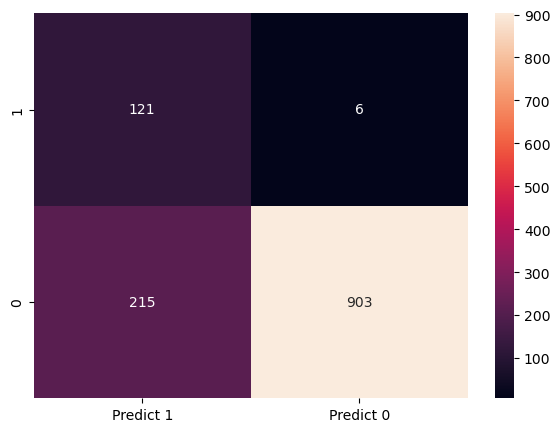

In [597]:
print("Confusion Matrix for the SVM Model")
cm_svm_tune1 = metrics.confusion_matrix(y_test,y_pred_SVM_tune1,labels=[1,0])

df_cm_svm_tune1 = pd.DataFrame(cm_svm_tune1,index=[i for i in ["1","0"]],
                        columns=[i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize=(7,5))
sns.heatmap(df_cm_svm_tune1,annot=True,fmt="g");

In [598]:
print("Classification Report for SVM Model")
print("__"*30)
print(metrics.classification_report(y_test,y_pred_SVM,labels=[1,0]))

Classification Report for SVM Model
____________________________________________________________
              precision    recall  f1-score   support

           1       0.35      0.96      0.52       127
           0       0.99      0.80      0.89      1118

    accuracy                           0.82      1245
   macro avg       0.67      0.88      0.70      1245
weighted avg       0.93      0.82      0.85      1245



In [599]:
print("Classification Report for KNN Model after tuning the parameters")
print("__"*30)
print(metrics.classification_report(y_test, y_pred_KNN_tune1, labels=[1, 0]))

Classification Report for KNN Model after tuning the parameters
____________________________________________________________
              precision    recall  f1-score   support

           1       0.37      0.96      0.53       127
           0       0.99      0.81      0.89      1118

    accuracy                           0.83      1245
   macro avg       0.68      0.89      0.71      1245
weighted avg       0.93      0.83      0.86      1245



When comparing the KNN model and the SVM model with the fine tuned parameter, we can infer the following:
- Accuracy is slightly higher in the KNN model
- For the value of 1, precision and F1-score are slightly higher for KNN

From the above 2 inferences we can conclude that the KNN model is slightly better than the SVM Model

**C. Print evaluation metrics for final model**

In [600]:
print("KNN Model score with test data: ",KNN_Model_tune1.score(X_test, y_test))
print("KNN Model score with training data: ",KNN_Model_tune1.score(X_train_smt,y_train_smt))

KNN Model score with test data:  0.8417670682730923
KNN Model score with training data:  0.9866942637492608


In [601]:
print("Classification Report for KNN Model after tuning the parameters")
print("__"*30)
print(metrics.classification_report(y_test, y_pred_KNN_tune1, labels=[1, 0]))

Classification Report for KNN Model after tuning the parameters
____________________________________________________________
              precision    recall  f1-score   support

           1       0.37      0.96      0.53       127
           0       0.99      0.81      0.89      1118

    accuracy                           0.83      1245
   macro avg       0.68      0.89      0.71      1245
weighted avg       0.93      0.83      0.86      1245



Confusion Matrix for the KNN Model


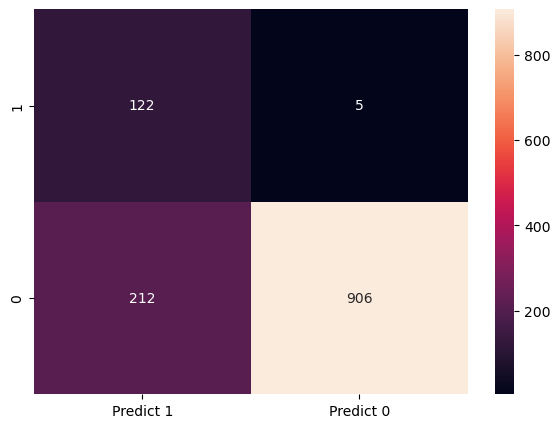

In [602]:
print("Confusion Matrix for the KNN Model")
cm_knn_tune1 = metrics.confusion_matrix(y_test,y_pred_KNN_tune1,labels=[1,0])

df_cm_knn_tune1 = pd.DataFrame(cm_knn_tune1,index=[i for i in ["1","0"]],
                        columns=[i for i in ["Predict 1","Predict 0"]])
plt.figure(figsize=(7,5))
sns.heatmap(df_cm_knn_tune1,annot=True,fmt="g");

**D. Share improvement achieved from base model to final model**

In the scenario that we are working on, we need to give more importance on the Recall value for the value of 1. <br>
The customers who are targetted are the customers who have loan on credit cards so the prediction on loan on cards should be given higher importance and hence the model selected should have a good recall value. <br>

In the base model the recall value was very poor(59%)
In the finalized KNN model the recall value is as high as 96%
There is a +37% improvement in the recall value for the KNN model